In [7]:
import numpy as np 
import pandas as pd 

In [8]:
df = pd.read_pickle("mos2_60_60_ttl.pkl")

In [9]:
len(df)

437010

In [33]:
import numpy as np
import pandas as pd

# Define number of bins (12x12 = 144)
n_bins = int(15)
theta_bins = np.linspace(df['Theta'].min(), df['Theta'].max(), n_bins + 1)
phi_bins = np.linspace(df['Phi'].min(), df['Phi'].max(), n_bins + 1)

# Digitize the grid positions
df['theta_bin'] = np.digitize(df['Theta'], theta_bins)
df['phi_bin'] = np.digitize(df['Phi'], phi_bins)

# Group by bins and pick row with smallest norm
sampled_df = (
    df
    .loc[df.groupby(['theta_bin', 'phi_bin'])['norm'].idxmin()]
    .drop(columns=['theta_bin', 'phi_bin'])
    .reset_index(drop=True)
)


In [34]:
len(sampled_df)

144

In [35]:
sampled_df['Deg_Diff'] = np.abs(sampled_df['Theta'] - sampled_df['Phi'])

In [36]:
final_df = sampled_df[((sampled_df['Deg_Diff']>1) & (sampled_df['Deg_Diff'] < 59)) & 
                      (((sampled_df['Phi'] > 1) & (sampled_df['Phi']<59)) | ((sampled_df['Phi']>61) & (sampled_df['Phi']<119))) &
                      ((sampled_df['Theta'] > 1) & (sampled_df['Theta']<59))
                      ]

In [37]:
len(final_df)

97

In [38]:
final_df.columns

Index(['Theta', 'Phi', 'A1', 'A2', 'delvec', 'delang', 'norm', 'Deg_Diff'], dtype='object')

In [39]:
final_df = final_df[['Theta', 'Deg_Diff', 'Phi', 'A1', 'A2', 'norm','delvec', 'delang']]

In [44]:
final_df.sort_values(by='norm', ascending=False).head(60)

,Theta,Deg_Diff,Phi,A1,A2,norm,delvec,delang,Theta_bin,Phi_bin
89,42.11,1.09,43.20,"[990.9577988966, 1250.2772715408]","[-587.2931770028, 1483.3333418938]",2763.253899,0.000464,5.561775e-06,"(42.0, 43.0]","(43.0, 44.0]"
71,33.99,1.02,35.01,"[-476.4831845248002, 1510.7517031118]","[1070.1078070846, 1168.0221878868]",2743.760148,0.000306,6.249053e-06,"(33.0, 34.0]","(35.0, 36.0]"
126,56.52,1.03,57.55,"[-554.0501252245999, 1085.7671042328002]","[663.276840647, 1022.7048734314001]",2111.299258,0.000586,4.477190e-06,"(56.0, 57.0]","(57.0, 58.0]"
44,23.48,1.56,25.04,"[272.27594010460007, 378.37338480840003]","[-191.54304989920007, 424.98459887900003]",807.404390,0.002745,5.053308e-06,"(23.0, 24.0]","(25.0, 26.0]"
117,53.39,2.72,56.11,"[248.53096758639998, 178.219347917]","[-30.0770394754, 304.3438095198]",529.706824,0.001282,7.481962e-06,"(53.0, 54.0]","(56.0, 57.0]"
26,16.43,2.13,18.56,"[6.331969840599996, 224.8305619876]","[197.8749788486, 106.9316087502]",389.572350,0.001387,7.617422e-06,"(16.0, 17.0]","(18.0, 19.0]"
78,34.96,50.57,85.53,"[163.04897422359997, 150.80098669900002]","[-49.07302712860002, 216.6050536222]",384.678717,0.001272,6.884612e-06,"(34.0, 35.0]",NaN
3,3.89,31.07,34.96,"[201.0409889608, 30.1601973398]","[74.400972209, 189.1866924042]",352.109829,0.001195,5.585578e-06,"(3.0, 4.0]","(34.0, 35.0]"
45,25.04,3.89,28.93,"[-12.664026575000001, 202.89587301319997]","[169.38097911379998, 112.4152809938]",352.109822,0.000351,7.570324e-06,"(25.0, 26.0]","(28.0, 29.0]"
108,49.01,1.56,50.57,"[-68.069022814, 189.18669240420002]","[129.8059750198, 153.54282282079998]",348.245563,0.000022,5.880663e-06,"(49.0, 50.0]","(50.0, 51.0]"


In [45]:
final_df.to_pickle("mos2_ttl_for_generation.pkl")

In [5]:
# Sort the DataFrame by 'degree' in ascending order and 'norm' in descending order, followed by 'vec_del' and 'delta_angle'
df_sorted = df.sort_values(by=['Theta','Phi', 'delvec', 'delang', 'norm'], ascending=[True, True, True, True, True])


In [6]:
df_sorted.head()

,Theta,Phi,A1,A2,delvec,delang,norm
372632,3.48,5.04,"[3346.4619042716004, -159.02649506440002]","[1810.951561414, 2818.6075332104]",0.001689,0.000003,5802.782518
372634,3.48,5.04,"[-3346.4619042716004, 159.02649506440002]","[-1810.951561414, -2818.6075332104]",0.001689,0.000003,5802.782518
372633,3.48,5.04,"[3346.4619042716004, -159.02649506440002]","[1535.5103428576, -2977.6340282747997]",0.001689,0.000008,5802.783148
372635,3.48,5.04,"[-3346.4619042716004, 159.02649506440002]","[-1535.5103428576, 2977.6340282747997]",0.001689,0.000008,5802.783148
372636,3.48,5.04,"[-1810.951561414, -2818.6075332104]","[-3346.4619042716004, 159.02649506440002]",0.001749,0.000003,5802.782518


In [7]:
final_df = df_sorted.groupby(['Theta', 'Phi'], as_index=False).first()


In [8]:
len(final_df)

16267

In [9]:
final_df.head()

,Theta,Phi,A1,A2,delvec,delang,norm
0,3.48,5.04,"[3346.4619042716004, -159.02649506440002]","[1810.951561414, 2818.6075332104]",0.001689,0.000003,5802.782518
1,3.48,5.20,"[-1741.2994565078006, -3624.7073530196003]","[2268.4393628912003, -3320.3635434997996]",0.001249,0.000003,6965.047469
2,3.48,5.57,"[2201.953073864, -1132.3783183034]","[2081.6447487466, 1340.7578635602001]",0.000870,0.000003,4288.663235
3,3.48,7.53,"[83.89916684060017, -1274.9537966369999]","[1146.0920351734, -564.8182410908]",0.002218,0.000005,2213.061117
4,3.48,8.33,"[1719.1383495864, -3076.3401286596]","[-1804.6195338876003, -3026.9870784672003]",0.001349,0.000004,6103.925788


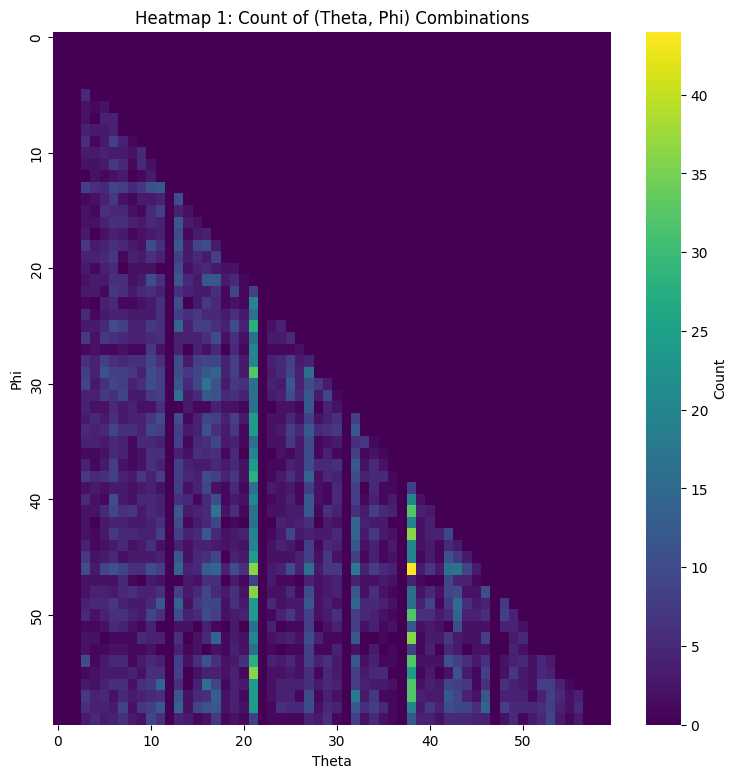

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose your DataFrame is already defined and imported as df
# Create bins from 0 to 60 with interval 0.5
bins = np.arange(0, 61, 1)

# Compute a 2D histogram:
# hist: the counts in each bin
# theta_edges and phi_edges are the bin edges for Theta and Phi respectively.
hist, theta_edges, phi_edges = np.histogram2d(final_df['Theta'], final_df['Phi'], bins=[bins, bins])

plt.figure(figsize=(9, 9))
sns.heatmap(hist.T,  # Transpose so that Theta is on the x-axis and Phi on the y-axis
            cmap="viridis",
            cbar_kws={'label': 'Count'},
            xticklabels=10,  # Adjust the frequency of x tick labels (or set to theta_edges if you prefer)
            yticklabels=10)
plt.xlabel("Theta")
plt.ylabel("Phi")
plt.title("Heatmap 1: Count of (Theta, Phi) Combinations")
plt.show()


/tmp/ipykernel_172204/3021259338.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = final_df.pivot_table(index='Phi_bin', columns='Theta_bin', values='norm', aggfunc='mean')


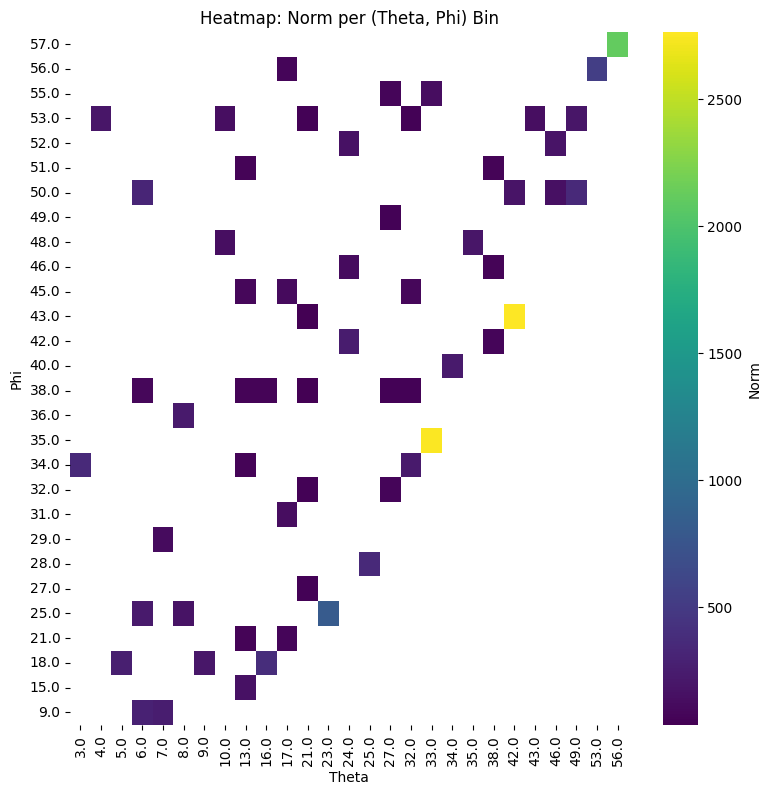

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define bins for Theta (x-axis) from 0 to 60 with a window of 0.5
theta_max = final_df['Theta'].max()
theta_bins = np.arange(0, theta_max+1, 1)

# Define bins for Phi (y-axis) from 0 to the maximum Phi in the data (plus one extra bin width)
phi_max = final_df['Deg_Diff'].max()
phi_bins = np.arange(0, phi_max + 1, 1)

# Bin the Theta and Phi columns
final_df['Theta_bin'] = pd.cut(final_df['Theta'], bins=theta_bins, include_lowest=True)
final_df['Phi_bin']   = pd.cut(final_df['Phi'], bins=phi_bins, include_lowest=True)

# Create a pivot table: rows for Phi_bin, columns for Theta_bin, values from 'norm'
pivot_table = final_df.pivot_table(index='Phi_bin', columns='Theta_bin', values='norm', aggfunc='mean')

# Map the bin intervals to their left edge (for cleaner numeric labels)
pivot_table.index = pivot_table.index.map(lambda x: x.left)
pivot_table.columns = pivot_table.columns.map(lambda x: x.left)

plt.figure(figsize=(9, 9))
ax = sns.heatmap(pivot_table, cmap="viridis", cbar_kws={'label': 'Norm'})

# Flip the y-axis so that the lowest Phi is at the bottom and highest at the top
ax.invert_yaxis()

plt.xlabel("Theta")
plt.ylabel("Phi")
plt.title("Heatmap: Norm per (Theta, Phi) Bin")
plt.show()


In [10]:
final_df['Deg_Diff'] = final_df['Phi'] - final_df['Theta']

In [11]:
final_df.head()

,Theta,Phi,A1,A2,delvec,delang,norm,Deg_Diff
0,3.48,5.04,"[3346.4619042716004, -159.02649506440002]","[1810.951561414, 2818.6075332104]",0.001689,0.000003,5802.782518,1.56
1,3.48,5.20,"[-1741.2994565078006, -3624.7073530196003]","[2268.4393628912003, -3320.3635434997996]",0.001249,0.000003,6965.047469,1.72
2,3.48,5.57,"[2201.953073864, -1132.3783183034]","[2081.6447487466, 1340.7578635602001]",0.000870,0.000003,4288.663235,2.09
3,3.48,7.53,"[83.89916684060017, -1274.9537966369999]","[1146.0920351734, -564.8182410908]",0.002218,0.000005,2213.061117,4.05
4,3.48,8.33,"[1719.1383495864, -3076.3401286596]","[-1804.6195338876003, -3026.9870784672003]",0.001349,0.000004,6103.925788,4.85


In [12]:
import pandas as pd

# Step 1: Theta filtering (same as before)
theta_matches = []

for i in range(61):  # Integers from 0 to 60
    theta_candidates = final_df[(final_df['Theta'] >= i - 0.2) & (final_df['Theta'] <= i + 0.2)]
    
    if not theta_candidates.empty:
        closest_theta = theta_candidates.loc[(theta_candidates['Theta'] - i).abs().idxmin(), 'Theta']
        matched_theta_rows = final_df[final_df['Theta'] == closest_theta]
        theta_matches.append(matched_theta_rows)

filtered_theta_df = pd.concat(theta_matches).reset_index(drop=True)

# Step 2: Phi filtering within each Theta group
phi_matches = []

# Loop through each unique Theta
for theta_val in filtered_theta_df['Theta'].unique():
    theta_group = filtered_theta_df[filtered_theta_df['Theta'] == theta_val]
    
    for j in range(131):  # Integers from 0 to 130
        phi_candidates = theta_group[(theta_group['Phi'] >= j - 0.2) & (theta_group['Phi'] <= j + 0.2)]
        
        if not phi_candidates.empty:
            closest_phi = phi_candidates.loc[(phi_candidates['Phi'] - j).abs().idxmin(), 'Phi']
            matched_phi_rows = theta_group[theta_group['Phi'] == closest_phi]
            phi_matches.append(matched_phi_rows)

# Combine all matched rows
final_filtered_df = pd.concat(phi_matches).reset_index(drop=True)


In [15]:
len(final_filtered_df)

1230

In [33]:


# Compute norms for each vector in A1 and A2
final_filtered_df['A1_norm'] = final_filtered_df['A1'].apply(lambda v: np.linalg.norm(v))
final_filtered_df['A2_norm'] = final_filtered_df['A2'].apply(lambda v: np.linalg.norm(v))

# Define a small tolerance for floating-point equality
tolerance = 0.001

# Filter rows where norms are (approximately) equal
final_filtered_df_filtered = final_filtered_df[np.abs(final_filtered_df['A1_norm'] - final_filtered_df['A2_norm']) < tolerance].copy()

# Drop the temporary norm columns if you want a clean DataFrame
final_filtered_df_filtered = final_filtered_df_filtered.drop(columns=['A1_norm', 'A2_norm'])


In [34]:
final_filtered_df.head()

,Theta,Phi,A1,A2,delvec,delang,norm,Theta_bin,Phi_bin,Deg_Diff,theta_bin,phi_bin,A1_norm,A2_norm
0,3.89,5.20,"[-1546.5905133284, -3249.0758043329997]","[2040.4873233914002, -2963.9248476658]",0.001117,2.723082e-06,6232.600674,"(3.0, 4.0]","(5.0, 6.0]",1.31,1,1,3598.393502,3598.393950
1,3.89,6.12,"[544.5520561874, -564.8182410908]","[-216.87089202139998, -754.0049334949999]",0.000690,2.787967e-07,1358.922187,"(3.0, 4.0]","(6.0, 7.0]",2.23,1,1,784.574144,784.574040
2,3.89,7.04,"[-378.33688565060004, -759.4886057386]","[468.56807782699997, -707.3937194243999]",0.001530,2.976324e-06,1469.654866,"(3.0, 4.0]","(7.0, 8.0]",3.15,1,1,848.505593,848.505697
3,3.89,9.90,"[-117.14197984340001, -120.6407893592]","[-163.0489997806, 41.127541827]",0.002282,2.243437e-07,291.254771,"(3.0, 4.0]","(9.0, 10.0]",6.01,1,1,168.156009,168.156032
4,3.89,13.03,"[3973.3300700342, -1568.3302616696]","[3344.8785293692, 2656.8392020242]",0.002703,1.726742e-06,7398.718052,"(3.0, 4.0]","(13.0, 14.0]",9.14,1,1,4271.652099,4271.651545


In [35]:
len(final_filtered_df_filtered)

1225

In [36]:
final_filtered_df_filtered.sort_values(by=['Theta', 'Phi'], ascending=True).head(50)

,Theta,Phi,A1,A2,delvec,delang,norm,Theta_bin,Phi_bin,Deg_Diff,theta_bin,phi_bin
0,3.89,5.20,"[-1546.5905133284, -3249.0758043329997]","[2040.4873233914002, -2963.9248476658]",0.001117,2.723082e-06,6232.600674,"(3.0, 4.0]","(5.0, 6.0]",1.31,1,1
1,3.89,6.12,"[544.5520561874, -564.8182410908]","[-216.87089202139998, -754.0049334949999]",0.000690,2.787967e-07,1358.922187,"(3.0, 4.0]","(6.0, 7.0]",2.23,1,1
2,3.89,7.04,"[-378.33688565060004, -759.4886057386]","[468.56807782699997, -707.3937194243999]",0.001530,2.976324e-06,1469.654866,"(3.0, 4.0]","(7.0, 8.0]",3.15,1,1
3,3.89,9.90,"[-117.14197984340001, -120.6407893592]","[-163.0489997806, 41.127541827]",0.002282,2.243437e-07,291.254771,"(3.0, 4.0]","(9.0, 10.0]",6.01,1,1
4,3.89,13.03,"[3973.3300700342, -1568.3302616696]","[3344.8785293692, 2656.8392020242]",0.002703,1.726742e-06,7398.718052,"(3.0, 4.0]","(13.0, 14.0]",9.14,1,1
5,3.89,13.85,"[-75.98350300020002, -3712.4461089172]","[3177.081144948, -1922.0271213818]",0.001307,3.541091e-06,6431.492453,"(3.0, 4.0]","(13.0, 14.0]",9.96,1,1
6,3.89,17.10,"[1106.5173384936, -2832.3167138194]","[-1899.5996174634, -2374.4300814788]",0.001513,5.609057e-06,5266.800897,"(3.0, 4.0]","(17.0, 18.0]",13.21,1,2
7,3.89,18.86,"[1635.2390162601998, -551.1090604818]","[1294.893802883, 1140.6038266688]",0.000391,9.629369e-07,2988.842990,"(3.0, 4.0]","(18.0, 19.0]",14.97,1,2
8,3.89,19.86,"[41.158318389800115, -2401.8484426968]","[2100.6410817844003, -1165.280351765]",0.000109,4.038789e-06,4160.734611,"(3.0, 4.0]","(19.0, 20.0]",15.97,1,2
9,3.89,20.97,"[3270.477874067, 87.73875589759996]","[1559.2545625396, 2876.1860917681997]",0.000992,4.163425e-06,5666.671502,"(3.0, 4.0]","(20.0, 21.0]",17.08,1,2


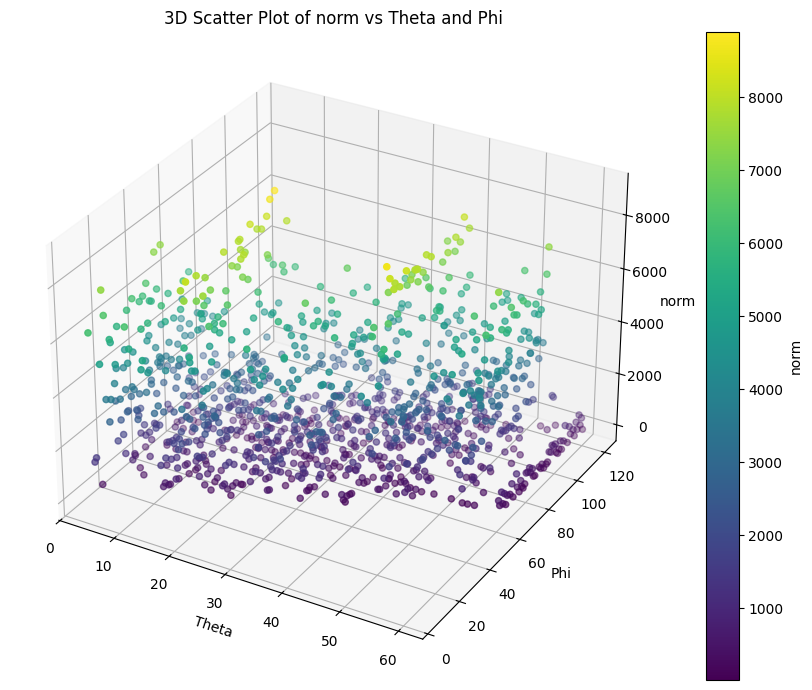

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D projection

# Make sure you're using the filtered data
df = final_filtered_df

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(df['Theta'], df['Phi'], df['norm'], c=df['norm'], cmap='viridis')

# Axis labels
ax.set_xlabel('Theta')
ax.set_ylabel('Phi')
ax.set_zlabel('norm')
ax.set_title('3D Scatter Plot of norm vs Theta and Phi')

# Optional: Add colorbar for norm values
fig.colorbar(sc, ax=ax, label='norm')

plt.tight_layout()
plt.show()


In [20]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata

df = final_filtered_df

# Create grid
theta_lin = np.linspace(df['Theta'].min(), df['Theta'].max(), 100)
phi_lin = np.linspace(df['Phi'].min(), df['Phi'].max(), 100)
Theta_grid, Phi_grid = np.meshgrid(theta_lin, phi_lin)

# Interpolate norm on grid
norm_grid = griddata(
    points=(df['Theta'], df['Phi']),
    values=df['norm'],
    xi=(Theta_grid, Phi_grid),
    method='linear'
)

fig = go.Figure()

# Add surface
fig.add_trace(go.Surface(x=Theta_grid, y=Phi_grid, z=norm_grid, colorscale='RdBu_r', opacity=0.9))

# Optional: Add scatter points on top
fig.add_trace(go.Scatter3d(
    x=df['Theta'], y=df['Phi'], z=df['norm'],
    mode='markers',
    marker=dict(size=3, color=df['norm'], colorscale='Viridis', colorbar=dict(title='norm')),
))

fig.update_layout(
    title='Interactive 3D Surface plot with Theta, Phi, and norm',
    scene=dict(
        xaxis_title='Theta',
        yaxis_title='Phi',
        zaxis_title='norm',
    ),
    width=2000,
    height=1000,
)

fig.show()


In [21]:
len(final_filtered_df)

1230

In [38]:

# Assuming your DataFrame is named final_filtered_df_filtered and contains 'Theta' and 'Phi' columns

# Define the number of bins to aim for ~100 points (e.g. 10x10 grid)
n_bins = int(np.sqrt(144))
theta_bins = np.linspace(final_filtered_df_filtered['Theta'].min(), final_filtered_df_filtered['Theta'].max(), n_bins + 1)
phi_bins = np.linspace(final_filtered_df_filtered['Phi'].min(), final_filtered_df_filtered['Phi'].max(), n_bins + 1)

# Digitize the grid positions
final_filtered_df_filtered['theta_bin'] = np.digitize(final_filtered_df_filtered['Theta'], theta_bins)
final_filtered_df_filtered['phi_bin'] = np.digitize(final_filtered_df_filtered['Phi'], phi_bins)

# Group by bins and take one sample per bin
sampled_final_filtered_df_filtered = final_filtered_df_filtered.groupby(['theta_bin', 'phi_bin'], group_keys=False).apply(lambda x: x.sample(1))

# Drop the temporary bin columns
sampled_final_filtered_df_filtered = sampled_final_filtered_df_filtered.drop(columns=['theta_bin', 'phi_bin']).reset_index(drop=True)


/tmp/ipykernel_64163/2259621360.py:13: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [40]:
len(sampled_final_filtered_df_filtered)

95

In [41]:
sampled_final_filtered_df_filtered.to_pickle("mos2_ttl_for_generation.pkl")